This notebook plots Fig. S5C-F and S10C-J. GO enrichment results were generated using Enrichr as described in the Methods; this notebook loads the resulting Enrichr output tables.

## Setup

In [1]:
# Set paths
SOD1_RENV_RNA="/oak/stanford/groups/agitler/Shared/Shared_Jupyter_Notebook_Analysis/4.1.1-OG-RNA/"
SOD1_RNA_DIR="/oak/stanford/groups/agitler/Shared/SOD1_Paper/RNA"

renv::load(SOD1_RENV_RNA)

# Load packages
suppressPackageStartupMessages({
  library(Seurat)
  library(SoupX)
  library(ggplot2)
  library(dplyr)
  library(BiocParallel)
  library(scDblFinder)
  library(svglite)
  library(pheatmap)
  library(matrixStats)
  library(tibble)
  library(DESeq2)
  library(VennDiagram)
  library(grid)
  library(stringr)
  library(ggrepel)
  library(ggrastr)
  library(ggpubr)
  library(forcats)
  library(ggbreak)
  library(cowplot)
  library(colorspace)
})

## Input paths

In [2]:
# Checkpoint and result-table inputs
alpha_label_transfer_file <- file.path(SOD1_RNA_DIR, "rds_files", "alpha_label_transfer_50.rds")

rna_dm_vs_non_dm_file <- file.path(SOD1_RNA_DIR, "DESeq2", "Other.Clusters_vs_Cluster.2.csv")
multiome_dm_vs_non_dm_file <- file.path(SOD1_RNA_DIR, "DESeq2", "alpha_multiome_RNA_nonDAMN_vs_DAMN.csv")
dai_multiome_rna_file <- file.path(SOD1_RNA_DIR, "DESeq2", "multiome_RNA_Non.Cholinergic.Interneurons_vs_Disease.Associated.Interneurons.csv")
damn_multiome_rna_file <- file.path(SOD1_RNA_DIR, "DESeq2", "alpha_multiome_RNA_nonDAMN_vs_DAMN.csv")

DAMN_up_GO_BP_file <- file.path(SOD1_RNA_DIR, "GO", "DAMN_up_GO_Biological_Process_2025.csv")
DAMN_down_GO_BP_file <- file.path(SOD1_RNA_DIR, "GO", "DAMN_down_GO_Biological_Process_2025.csv")
DAI_up_GO_BP_file <- file.path(SOD1_RNA_DIR, "GO", "DAI_Up_GO_Biological_Process_2025_table.csv")
DAI_down_GO_BP_file <- file.path(SOD1_RNA_DIR, "GO", "DAI_Down_GO_Biological_Process_2025_table.csv")

## RNA-only vs. multiome RNA DAMN/DM differential expression concordance

Joining, by = c("baseMean.x", "log2FoldChange.x", "lfcSE.x", "stat.x", "pvalue.x", "padj.x", "gene", "baseMean.y", "log2FoldChange.y", "lfcSE.y", "stat.y", "pvalue.y", "padj.y")
Joining, by = c("baseMean.x", "log2FoldChange.x", "lfcSE.x", "stat.x", "pvalue.x", "padj.x", "gene", "baseMean.y", "log2FoldChange.y", "lfcSE.y", "stat.y", "pvalue.y", "padj.y")


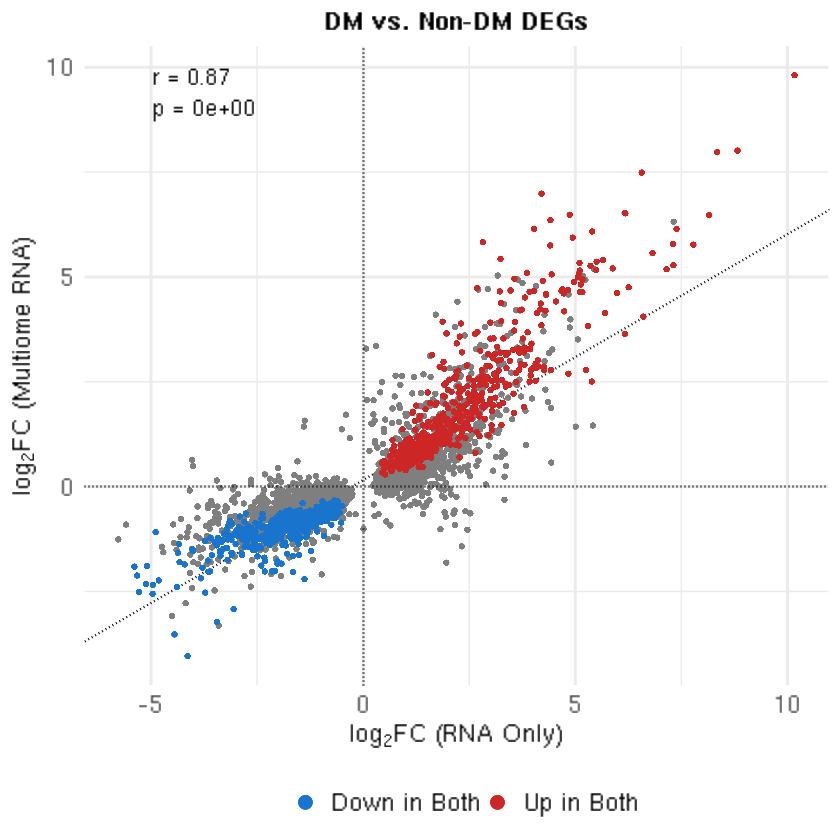

In [3]:
alpha_rna_only <- read.csv(rna_dm_vs_non_dm_file, row.names = 1)
alpha_rna_only$log2FoldChange <- -1 * alpha_rna_only$log2FoldChange
alpha_rna_only$stat <- -1 * alpha_rna_only$stat

alpha_multiome_rna <- read.csv(multiome_dm_vs_non_dm_file, row.names = 1)
alpha_multiome_rna$log2FoldChange <- -1 * alpha_multiome_rna$log2FoldChange
alpha_multiome_rna$stat <- -1 * alpha_multiome_rna$stat

alpha_rna_only$gene <- rownames(alpha_rna_only)
alpha_multiome_rna$gene <- rownames(alpha_multiome_rna)

damn_combo <- dplyr::inner_join(alpha_rna_only, alpha_multiome_rna, by = "gene")

damn_combo_filtered <- damn_combo %>% dplyr::filter(padj.x < 0.01 | padj.y < 0.01)

# Calculate correlation coefficient
correlation_value <- cor(damn_combo_filtered$log2FoldChange.x, damn_combo_filtered$log2FoldChange.y)

# Create separate dataframes for each group of points
firebrick_df <- subset(damn_combo_filtered, padj.x < 0.01 & padj.y < 0.01 & log2FoldChange.x > 0 & log2FoldChange.y > 0)
dodgerblue_df <- subset(damn_combo_filtered, padj.x < 0.01 & padj.y < 0.01 & log2FoldChange.x < 0 & log2FoldChange.y < 0)
gray_df <- dplyr::anti_join(damn_combo_filtered, firebrick_df) %>% dplyr::anti_join(dodgerblue_df)

# -----------------------------
# Correlation + p-value + LM fit
# -----------------------------
xy <- damn_combo_filtered[, c("log2FoldChange.x", "log2FoldChange.y")]
xy <- xy[stats::complete.cases(xy), , drop = FALSE]

cor_test <- stats::cor.test(
  xy$log2FoldChange.x,
  xy$log2FoldChange.y,
  method = "pearson"
)

correlation_value <- unname(cor_test$estimate)
p_value <- cor_test$p.value

fmt_p <- function(p) {
  if (is.na(p)) return("NA")
  if (p < 1e-3) format(p, scientific = TRUE, digits = 2) else sprintf("%.3f", p)
}

fit <- stats::lm(log2FoldChange.y ~ log2FoldChange.x, data = xy)
b0 <- unname(stats::coef(fit)[1])  # intercept
b1 <- unname(stats::coef(fit)[2])  # slope

# Annotation placement
x_rng <- range(xy$log2FoldChange.x, na.rm = TRUE)
y_rng <- range(xy$log2FoldChange.y, na.rm = TRUE)
ann_x <- x_rng[1] + 0.05 * diff(x_rng)
ann_y <- y_rng[2] - 0.03 * diff(y_rng)

# -----------------------------
# Plot
# -----------------------------
damn_four_way <- ggplot() +

  # Best-fit line 
  geom_abline(
    intercept = b0,
    slope = b1,
    linetype = "dotted"
  ) +

  geom_point(
    data = gray_df,
    aes(x = log2FoldChange.x, y = log2FoldChange.y, color = "DE one study"),
    size = 1
  ) +
  geom_point(
    data = firebrick_df,
    aes(x = log2FoldChange.x, y = log2FoldChange.y, color = "Up in Both"),
    size = 1
  ) +
  geom_point(
    data = dodgerblue_df,
    aes(x = log2FoldChange.x, y = log2FoldChange.y, color = "Down in Both"),
    size = 1
  ) +

  geom_vline(xintercept = 0, linetype = "dotted") +
  geom_hline(yintercept = 0, linetype = "dotted") +

  labs(
    title = "DM vs. Non-DM DEGs",
    x = expression(log[2]*"FC (RNA Only)"),
    y = expression(log[2]*"FC (Multiome RNA)"),
    color = NULL
  ) +

  annotate(
    "text",
    x = ann_x,
    y = ann_y,
    hjust = 0,
    label = paste0("r = ", round(correlation_value, 2), "\np = ", fmt_p(p_value)),
    size = 4.5
  ) +

  scale_color_manual(
    values = c(
      "Up in Both" = "firebrick3",
      "Down in Both" = "dodgerblue3",
      "DE one study" = "gray50"
    ),
    breaks = c("Down in Both", "Up in Both")
  ) +

  guides(color = guide_legend(override.aes = list(size = 3))) +

  theme_minimal(base_size = 14) +
  theme(
    legend.position = "bottom",
    legend.title = element_blank(),
    legend.text = element_text(size = 14),
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 14),
    plot.title = element_text(size = 14, face = "bold", hjust = 0.5)
  )

# -----------------------------
# Rasterize points
# -----------------------------
damn_four_way <- rasterize(damn_four_way, layers = "Point", dpi = 1000)
damn_four_way

## Cross-modal label transfer UMAP

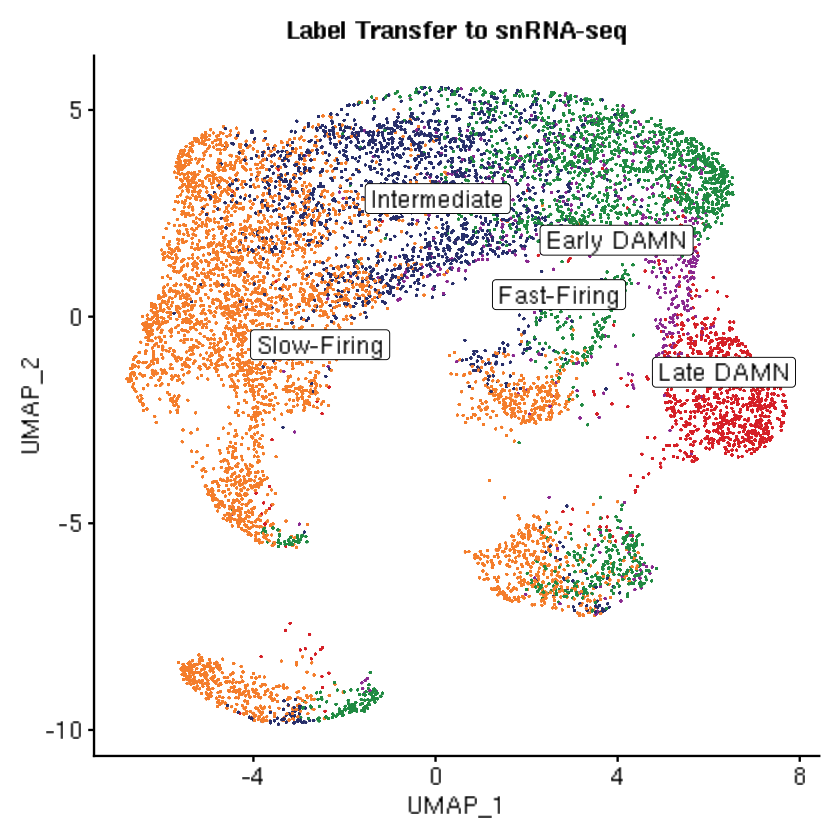

In [4]:
alpha_label_transfer_50 <- readRDS(alpha_label_transfer_file)

# Colors
alpha_colors <- c(
  "Slow-Firing"  = '#F47D2B',
  "Intermediate" = '#272E6A',
  "Fast-Firing"  = '#208A42',
  "Early DAMN"   = '#89288F',
  "Late DAMN"    = '#D51F26'
)

# Base UMAP without labels
p <- DimPlot(
  alpha_label_transfer_50,
  reduction = "umap",
  group.by  = "predicted.id",
  cols      = alpha_colors,
  label     = FALSE
) +
  ggtitle("Label Transfer to snRNA-seq") +
  theme(
    plot.title = element_text(size = 14, hjust = 0.5),
    axis.text  = element_text(size = 14),
    axis.title = element_text(size = 14)
  ) +
  NoLegend()

# Compute cluster centers for labels 
emb <- Embeddings(alpha_label_transfer_50, "umap")
emb_df <- as.data.frame(emb)
emb_df$predicted.id <- alpha_label_transfer_50$predicted.id
centers <- aggregate(emb_df[, 1:2], by = list(predicted.id = emb_df$predicted.id), FUN = mean)
colnames(centers)[2:3] <- colnames(emb)[1:2]  

# Add ggrepel labels with white, rounded background
p <- p + geom_label_repel(
  data = centers,
  aes_string(x = colnames(emb)[1], y = colnames(emb)[2], label = "predicted.id"),
  size       = 14 / 2.845,  
  fill       = "white",
  label.r    = grid::unit(0.15, "lines"),  
  label.size = 0.2,            
  segment.size = 0.2,          
  max.overlaps = Inf,          
  box.padding  = 0.3,         
  point.padding = 0.2
)

# Rasterize points 
alpha_label_transfer_UMAP <- rasterize(p, layers = "Point", dpi = 1000)
alpha_label_transfer_UMAP

## RNA-only cluster 7 stage composition

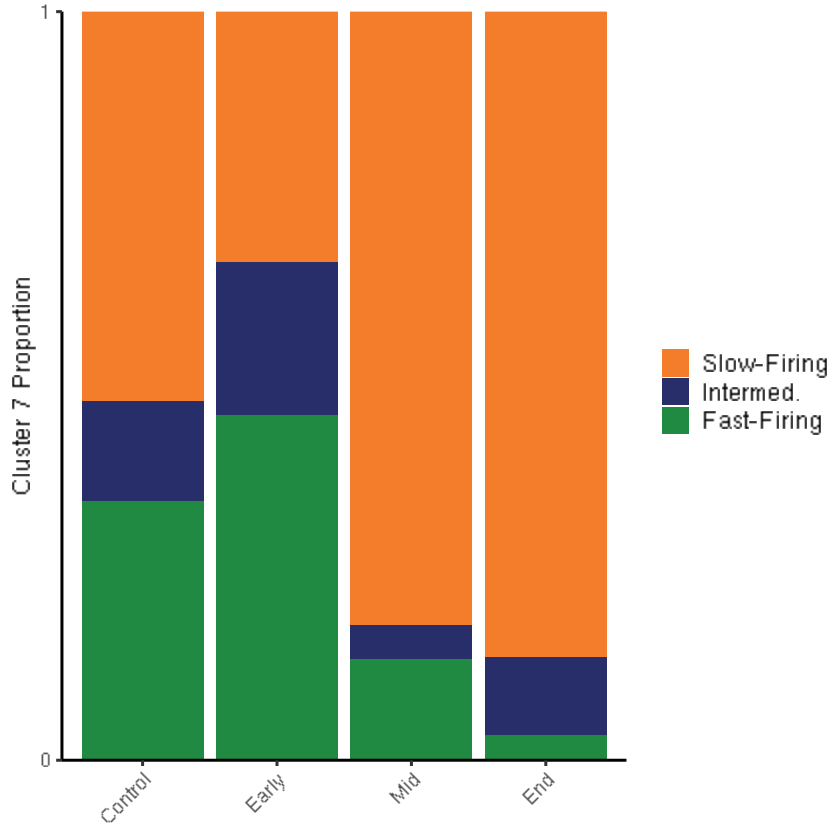

In [5]:
alpha_c7 <- subset(alpha_label_transfer_50, subset = seurat_clusters == 7)
alpha_c7_nonDAMN <- subset(alpha_c7, subset = predicted.id %in% c("Fast-Firing", "Intermediate", "Slow-Firing"))

# Extract and clean metadata (force plain data.frame and atomic columns)
meta <- alpha_c7_nonDAMN@meta.data %>%
  as.data.frame() %>%                                   
  dplyr::select(stage, predicted.id) %>%
  dplyr::filter(!is.na(stage), !is.na(predicted.id)) %>%
  dplyr::mutate(
    stage = factor(as.character(stage),
                   levels = c("ctl", "sod.early", "sod.mid", "sod.end")),
    Category = dplyr::recode(as.character(predicted.id),
                              "Intermediate" = "Intermed.",
                              "Fast-Firing"  = "Fast-Firing",
                              "Slow-Firing"  = "Slow-Firing")
  ) %>%
  dplyr::filter(Category %in% c("Slow-Firing", "Intermed.", "Fast-Firing"))

# Summarize counts and within-stage proportions 
long_df <- meta %>%
  dplyr::group_by(stage, Category) %>%
  dplyr::summarise(Count = dplyr::n(), .groups = "drop_last") %>%
  dplyr::mutate(Proportion = Count / sum(Count)) %>%
  dplyr::ungroup()

# Factor order for stacking
long_df$Category <- factor(long_df$Category,
                           levels = c("Slow-Firing", "Intermed.", "Fast-Firing"))

# Colors
alpha_colors <- c("Slow-Firing" = '#F47D2B',
                  "Intermed."   = '#272E6A',
                  "Fast-Firing" = '#208A42')

# Plot: stacked proportions by stage
c7_stage_composition_plot <- ggplot(long_df, aes(x = stage, y = Proportion, fill = Category)) +
  geom_bar(stat = "identity", position = "fill") +
  scale_y_continuous(breaks = c(0, 1), expand = c(0, 0)) +
  scale_x_discrete(labels = c("Control", "Early", "Mid", "End")) +
  scale_fill_manual(values = alpha_colors) +
  labs(y = "Cluster 7 Proportion", x = NULL, fill = NULL) +
  theme_classic(base_size = 14) +        # sets global base font size
  theme(
    text = element_text(size = 14),      # guarantees ALL text is 14
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.text = element_text(size = 14),
    legend.title = element_text(size = 14)
  )

c7_stage_composition_plot

## Early DAMN/DM next-most-probable subtype comparison

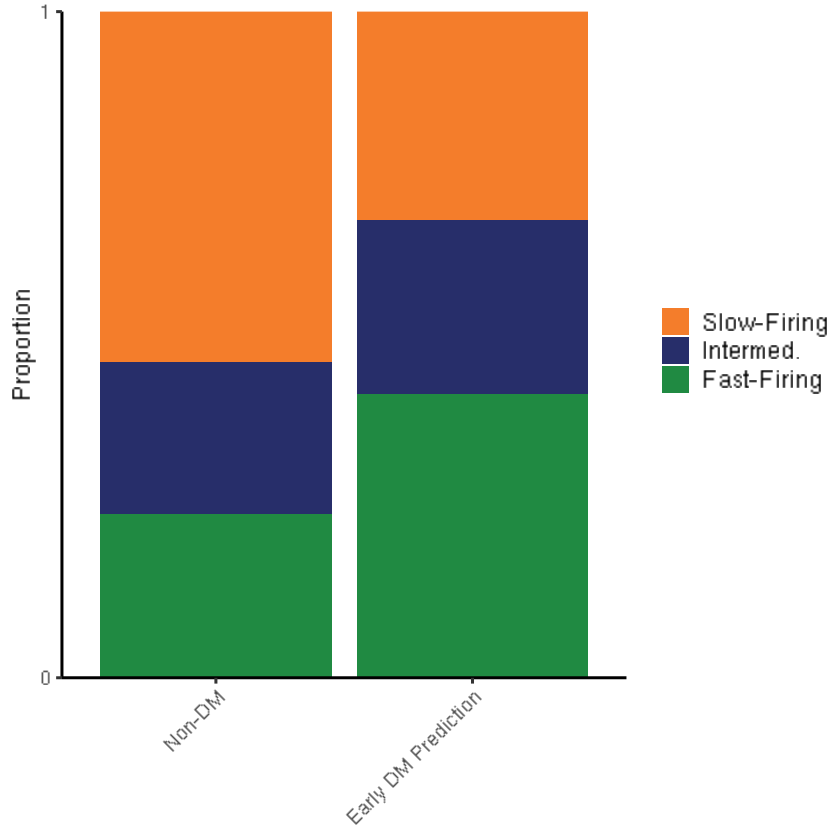

In [6]:
alpha_label_transfer_earlyDAMN <- subset(alpha_label_transfer_50, subset = predicted.id == "Early DAMN")

alpha_label_transfer_earlyDAMN$nonDAMN_identitiy <- apply(alpha_label_transfer_earlyDAMN@meta.data[, c("prediction.score.Slow.Firing",
                                                        "prediction.score.Fast.Firing",
                                                        "prediction.score.Intermediate")], 1, function(x) {
  if (x["prediction.score.Fast.Firing"] > x["prediction.score.Slow.Firing"] &&
      x["prediction.score.Fast.Firing"] > x["prediction.score.Intermediate"]) {
    return("Fast-Firing")
  } else if (x["prediction.score.Slow.Firing"] > x["prediction.score.Fast.Firing"] &&
             x["prediction.score.Slow.Firing"] > x["prediction.score.Intermediate"]) {
    return("Slow-Firing")
  } else if (x["prediction.score.Slow.Firing"] == x["prediction.score.Fast.Firing"] &&
             x["prediction.score.Slow.Firing"] == x["prediction.score.Intermediate"]) {
    return(NA)
  } else {
    return("Intermediate")
  }
})

predicted_nonDAMN_id_counts <- table(alpha_label_transfer_earlyDAMN$nonDAMN_identitiy)

alpha_label_transfer_nonDAMN <- subset(alpha_label_transfer_50, subset = predicted.id %in% c("Fast-Firing", "Intermediate", "Slow-Firing"))

nonDAMN_id_counts <- table(alpha_label_transfer_nonDAMN$predicted.id)

# Create a dataframe
combined_df <- data.frame(
  Category = names(predicted_nonDAMN_id_counts),
  ED_Predict. = as.numeric(predicted_nonDAMN_id_counts),
  ND = as.numeric(nonDAMN_id_counts)
)

# Replace "Intermediate" with "Intermed." in the Category column
combined_df <- combined_df %>%
  mutate(Category = ifelse(Category == "Intermediate", "Intermed.", Category))

# Convert to long format and rename condition labels
long_df <- combined_df %>%
  tidyr::pivot_longer(cols = c("ND", "ED_Predict."), names_to = "Condition", values_to = "Count") %>%
  mutate(
    Condition = recode(Condition,
                       "ND" = "Non-DM",
                       "ED_Predict." = "Early DM Prediction")
  ) %>%
  group_by(Condition) %>%
  mutate(Proportion = Count / sum(Count))

# Factor levels
long_df$Category <- factor(long_df$Category, levels = c("Slow-Firing", "Intermed.", "Fast-Firing"))
long_df$Condition <- factor(long_df$Condition, levels = c("Non-DM", "Early DM Prediction"))

# Colors
alpha_colors <- c("Slow-Firing" = '#F47D2B', "Intermed." = '#272E6A', "Fast-Firing" = '#208A42')

# Plot
early_DAMN_prediction_bar_plot <- ggplot(long_df, aes(x = Condition, y = Proportion, fill = Category)) +
  geom_bar(stat = "identity", position = "fill") +
  scale_y_continuous(breaks = c(0, 1), expand = c(0, 0)) +
  labs(y = "Proportion", fill = NULL) +
  scale_fill_manual(values = alpha_colors) +
  theme_classic(base_size = 14) +   # sets global base font size
  theme(
    text = element_text(size = 14),  # ensures ALL text is 14
    axis.title.x = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.text = element_text(size = 14),
    legend.title = element_text(size = 14)
  )

early_DAMN_prediction_bar_plot

## Alpha MN ligand UMAPs

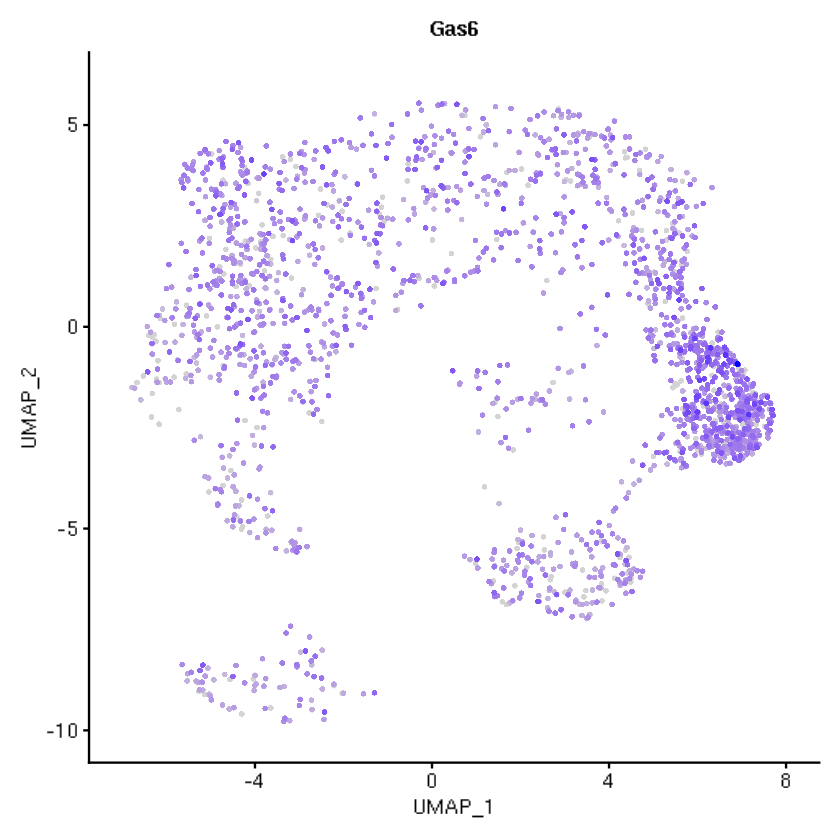

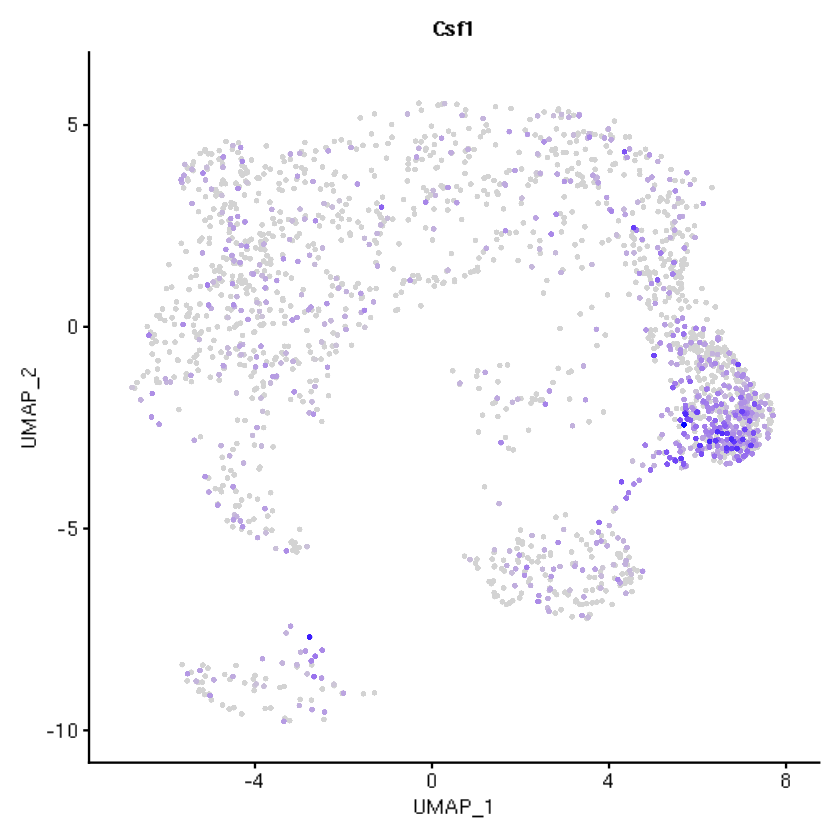

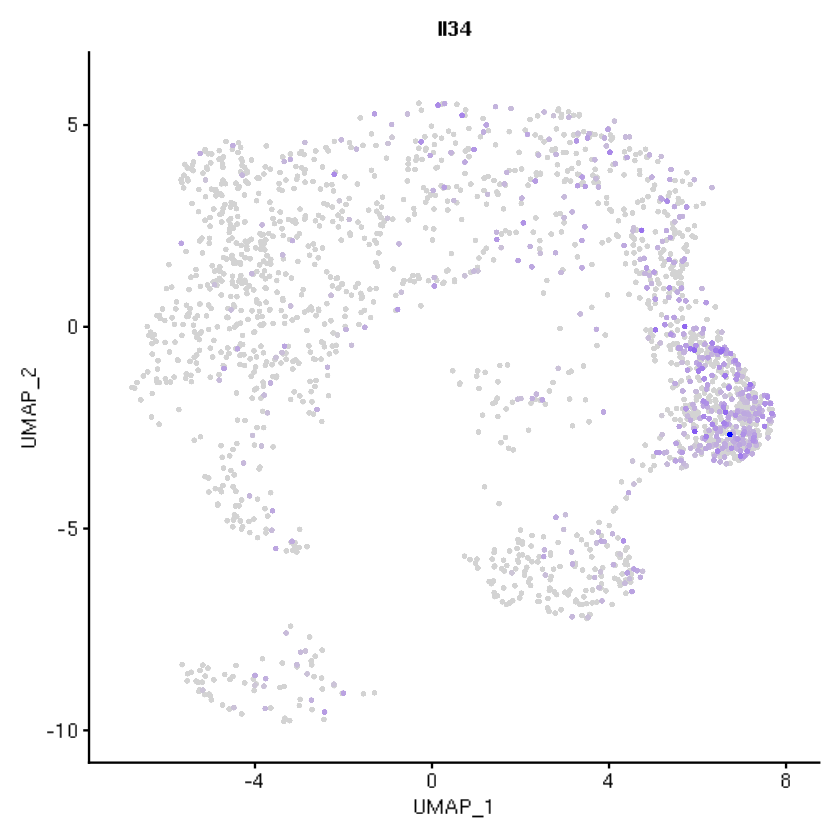

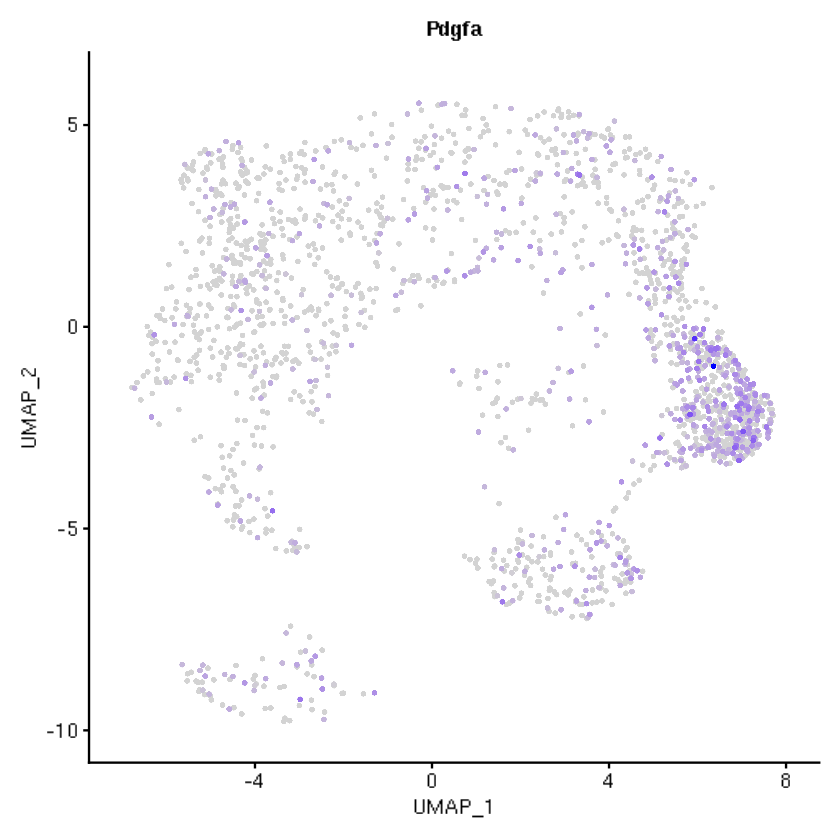

In [7]:
alpha_end <- subset(alpha_label_transfer_50, subset = stage == "sod.end")
DefaultAssay(alpha_end) <- "RNA"

# Base theme
common_theme <- theme(
  plot.title   = element_text(hjust = 0.5, size = 11.56),
  axis.title   = element_text(size = 11.56),
  axis.text    = element_text(size = 11.56),
  text         = element_text(size = 11.56)
)

genes_to_plot  <- c("Gas6", "Csf1", "Il34", "Pdgfa")
genes_present  <- genes_to_plot[genes_to_plot %in% rownames(alpha_end)]

# Create and print plots
gene_plots <- list()
for (g in genes_present) {
  p <- FeaturePlot(
    alpha_end,
    features  = g,
    reduction = "umap",
    order     = TRUE
  ) +
    ggtitle(g) +
    common_theme +
    NoLegend()

  # Rasterize points
  p <- rasterize(p, layers = "Point", dpi = 1000)

  gene_plots[[g]] <- p
  assign(g, p, envir = .GlobalEnv)
  print(p)
}

## Disease-associated interneuron (DAI) vs. non-cholinergic interneuron volcano

In [8]:
make_volcano_plot <- function(data, labeled_pts=0, labeled_genes=NULL, p_val_cutoff=0.01) {
  data <- data %>% 
    mutate(
      Expression = case_when(
        log2FoldChange >= 0 & padj <= p_val_cutoff ~ "Up-regulated",
        log2FoldChange <= 0 & padj <= p_val_cutoff ~ "Down-regulated",
        TRUE ~ "Unchanged"
      )
    )
  
  top <- labeled_pts
  top_genes <- bind_rows(
    data %>% 
      filter(Expression == 'Up-regulated') %>% 
      arrange(padj, desc(abs(log2FoldChange))) %>% 
      head(top),
    data %>% 
      filter(Expression == 'Down-regulated') %>% 
      arrange(padj, desc(abs(log2FoldChange))) %>% 
      head(top),
    data %>% 
      filter(gene %in% labeled_genes)
  )
  
  x_scale <- max(abs(data$log2FoldChange), na.rm = TRUE)
  
  p1 <- ggplot(data, aes(log2FoldChange, -log10(padj))) +
    geom_point(aes(color = Expression), size = 4/5) +
    geom_label_repel(
      data = top_genes,
      mapping = aes(log2FoldChange, -log10(padj), label = gene),
      size = 4.5,  
      force = 0.01
    ) +
    xlim(-x_scale, x_scale) +
    xlab(expression("log"[2]*"FC")) + 
    ylab(expression("-log"[10]*"(padj)")) + 
    scale_color_manual(values = c("dodgerblue3", "gray50", "firebrick3")) + 
    guides(colour = guide_legend(override.aes = list(size = 1.5))) + 
    theme_classic(base_size = 14) +
    theme(
      axis.text       = element_text(size = 14),
      axis.title      = element_text(size = 14),
      legend.text     = element_text(size = 14),
      legend.title    = element_text(size = 14),
      plot.title      = element_text(size = 14, hjust = 0.5),
      strip.text      = element_text(size = 14)
    )
  
  return(p1)
}

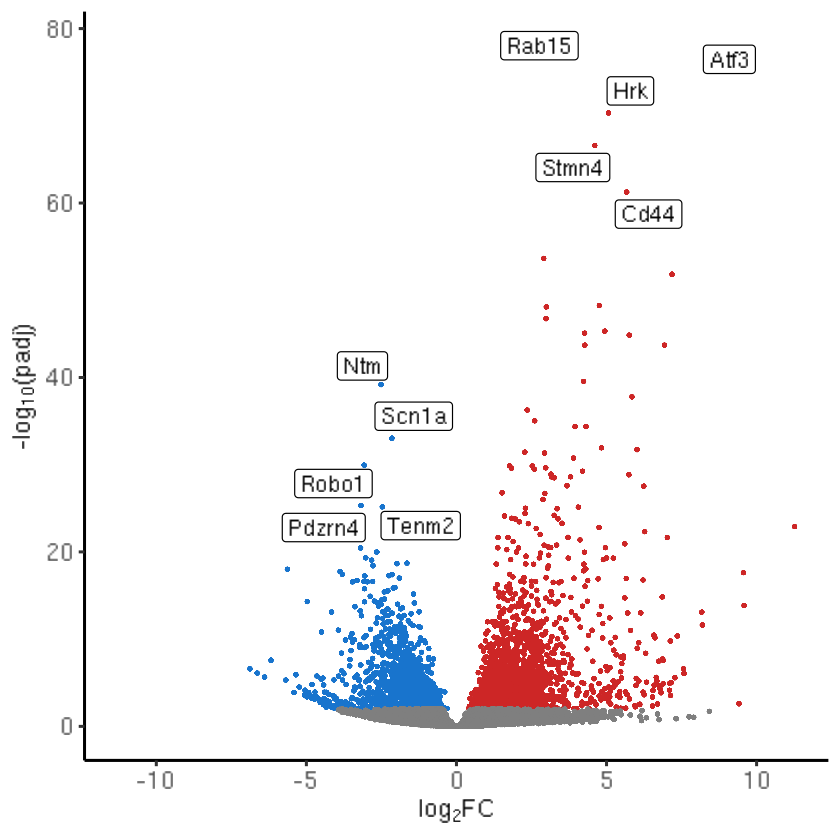

In [9]:
dai_multiome_rna <- read.csv(dai_multiome_rna_file, row.names = 1)
dai_multiome_rna$log2FoldChange <- -1 * dai_multiome_rna$log2FoldChange
dai_multiome_rna$stat <- -1 * dai_multiome_rna$stat
dai_multiome_rna$gene <- rownames(dai_multiome_rna)
rownames(dai_multiome_rna) <- NULL

dai_volcano_plot <- make_volcano_plot(dai_multiome_rna, 5, p_val_cutoff = 0.01)
dai_volcano_plot <- rasterize(dai_volcano_plot, layers="Point", dpi=1000) + NoLegend()
dai_volcano_plot

## DAI vs. DAMN/DM differential expression concordance

Joining, by = c("baseMean.x", "log2FoldChange.x", "lfcSE.x", "stat.x", "pvalue.x", "padj.x", "gene", "baseMean.y", "log2FoldChange.y", "lfcSE.y", "stat.y", "pvalue.y", "padj.y")
Joining, by = c("baseMean.x", "log2FoldChange.x", "lfcSE.x", "stat.x", "pvalue.x", "padj.x", "gene", "baseMean.y", "log2FoldChange.y", "lfcSE.y", "stat.y", "pvalue.y", "padj.y")


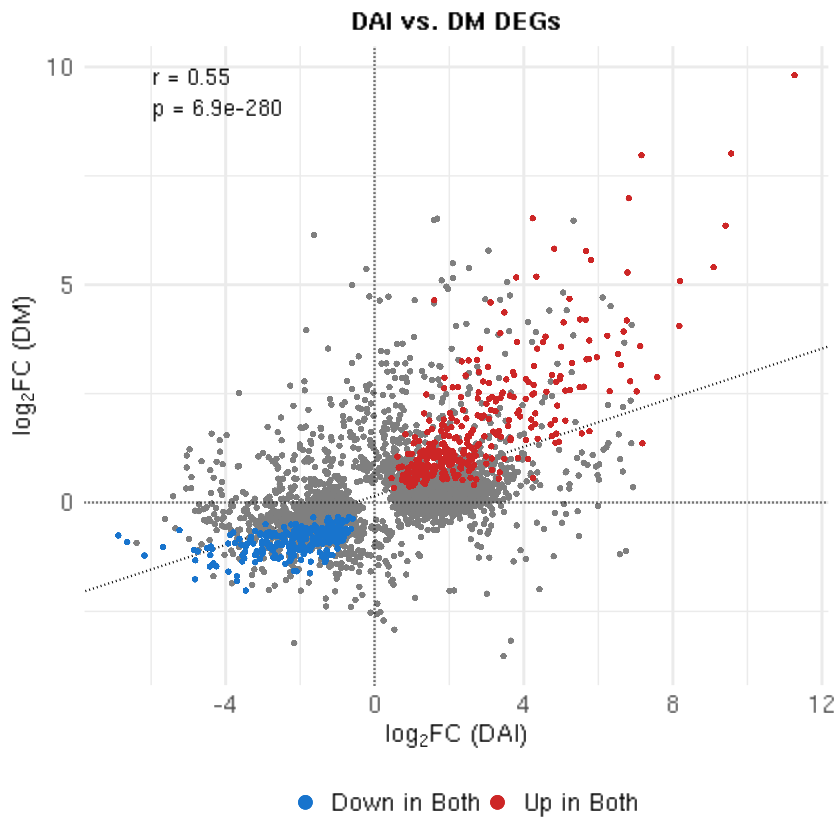

In [10]:
dai_multiome_rna <- read.csv(dai_multiome_rna_file, row.names = 1)
damn_multiome_rna <- read.csv(damn_multiome_rna_file, row.names = 1)

dai_multiome_rna$log2FoldChange <- -1 * dai_multiome_rna$log2FoldChange
dai_multiome_rna$stat <- -1 * dai_multiome_rna$stat

damn_multiome_rna$log2FoldChange <- -1 * damn_multiome_rna$log2FoldChange
damn_multiome_rna$stat <- -1 * damn_multiome_rna$stat

dai_multiome_rna$gene <- rownames(dai_multiome_rna)
damn_multiome_rna$gene <- rownames(damn_multiome_rna)

dai_damn_combo <- dplyr::inner_join(dai_multiome_rna, damn_multiome_rna, by = "gene")

dai_damn_combo_filtered <- dai_damn_combo %>% dplyr::filter(padj.x < 0.01 | padj.y < 0.01)

# Calculate correlation coefficient
correlation_value <- cor(dai_damn_combo_filtered$log2FoldChange.x, dai_damn_combo_filtered$log2FoldChange.y)

# Create separate dataframes for each group of points
firebrick_df <- subset(dai_damn_combo_filtered, padj.x < 0.01 & padj.y < 0.01 & log2FoldChange.x > 0 & log2FoldChange.y > 0)
dodgerblue_df <- subset(dai_damn_combo_filtered, padj.x < 0.01 & padj.y < 0.01 & log2FoldChange.x < 0 & log2FoldChange.y < 0)
gray_df <- dplyr::anti_join(dai_damn_combo_filtered, firebrick_df) %>% dplyr::anti_join(dodgerblue_df)

# -----------------------------
# Correlation + p-value + LM fit
# -----------------------------
xy <- dai_damn_combo_filtered[, c("log2FoldChange.x", "log2FoldChange.y")]
xy <- xy[stats::complete.cases(xy), , drop = FALSE]

cor_test <- stats::cor.test(
  xy$log2FoldChange.x,
  xy$log2FoldChange.y,
  method = "pearson"
)

correlation_value <- unname(cor_test$estimate)
p_value <- cor_test$p.value

fmt_p <- function(p) {
  if (is.na(p)) return("NA")
  if (p < 1e-3) format(p, scientific = TRUE, digits = 2) else sprintf("%.3f", p)
}

# Fit linear model once
fit <- stats::lm(log2FoldChange.y ~ log2FoldChange.x, data = xy)
b0 <- unname(stats::coef(fit)[1])  # intercept
b1 <- unname(stats::coef(fit)[2])  # slope

# Annotation placement
x_rng <- range(xy$log2FoldChange.x, na.rm = TRUE)
y_rng <- range(xy$log2FoldChange.y, na.rm = TRUE)
ann_x <- x_rng[1] + 0.05 * diff(x_rng)
ann_y <- y_rng[2] - 0.03 * diff(y_rng)

# -----------------------------
# Plot
# -----------------------------
dai_damn_four_way <- ggplot() +

  # Best-fit line drawn as an abline
  geom_abline(
    intercept = b0,
    slope = b1,
    linetype = "dotted"
  ) +

  geom_point(
    data = gray_df,
    aes(x = log2FoldChange.x, y = log2FoldChange.y, color = "DE one study"),
    size = 1
  ) +
  geom_point(
    data = firebrick_df,
    aes(x = log2FoldChange.x, y = log2FoldChange.y, color = "Up in Both"),
    size = 1
  ) +
  geom_point(
    data = dodgerblue_df,
    aes(x = log2FoldChange.x, y = log2FoldChange.y, color = "Down in Both"),
    size = 1
  ) +

  geom_vline(xintercept = 0, linetype = "dotted") +
  geom_hline(yintercept = 0, linetype = "dotted") +

  labs(
    title = "DAI vs. DM DEGs",
    x = expression(log[2]*"FC (DAI)"),
    y = expression(log[2]*"FC (DM)"),
    color = NULL
  ) +

  annotate(
    "text",
    x = ann_x,
    y = ann_y,
    hjust = 0,
    label = paste0("r = ", round(correlation_value, 2), "\np = ", fmt_p(p_value)),
    size = 4.5
  ) +

  scale_color_manual(
    values = c(
      "Up in Both" = "firebrick3",
      "Down in Both" = "dodgerblue3",
      "DE one study" = "gray50"
    ),
    breaks = c("Down in Both", "Up in Both")
  ) +

  guides(color = guide_legend(override.aes = list(size = 3))) +

  theme_minimal(base_size = 14) +
  theme(
    legend.position = "bottom",
    legend.title = element_blank(),
    legend.text = element_text(size = 14),
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 14),
    plot.title = element_text(size = 14, face = "bold", hjust = 0.5)
  )

# -----------------------------
# Rasterize points 
# -----------------------------
dai_damn_four_way <- rasterize(dai_damn_four_way, layers = "Point", dpi = 1000)
dai_damn_four_way

## DAI vs. DAMN/DM GO concordance

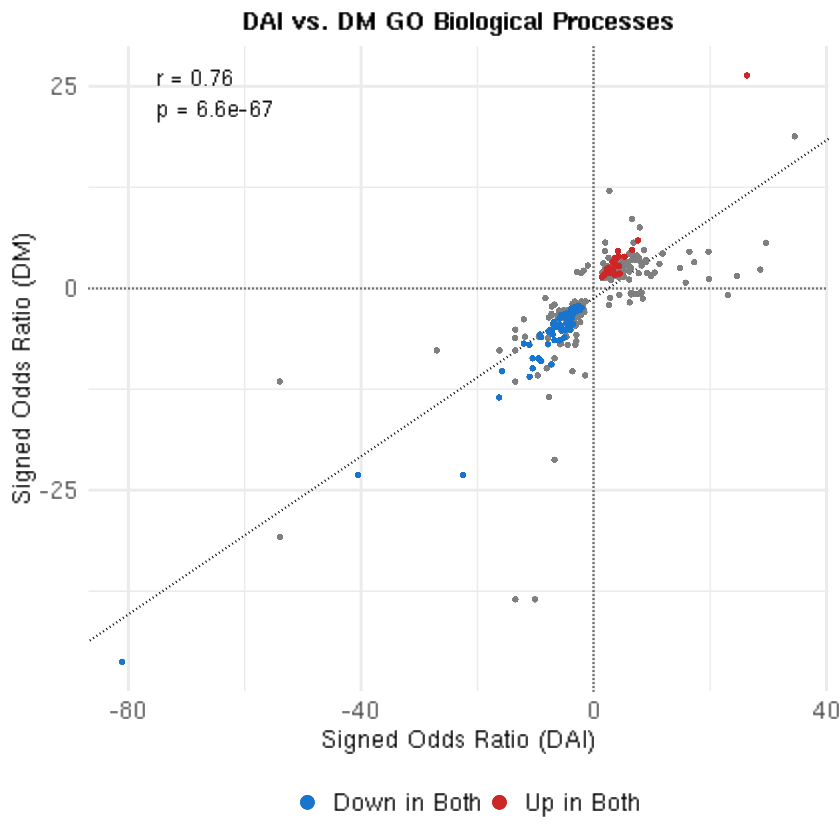

In [11]:
DAMN_up_GO_BP <- read.csv(DAMN_up_GO_BP_file)
DAMN_down_GO_BP <- read.csv(DAMN_down_GO_BP_file)
DAI_up_GO_BP <- read.csv(DAI_up_GO_BP_file)
DAI_down_GO_BP <- read.csv(DAI_down_GO_BP_file)

padj_thresh <- 0.01

# -----------------------------
# Make DAI and DAMN term-level tables
# -----------------------------
make_side <- function(up_df, down_df, suffix = c("x","y")) {
  suffix <- match.arg(suffix)

  bind_rows(
    up_df %>%
      transmute(
        Term = as.character(Term),
        padj = suppressWarnings(as.numeric(Adjusted.P.value)),
        OR   = suppressWarnings(as.numeric(Odds.Ratio)),
        direction = "up"
      ),
    down_df %>%
      transmute(
        Term = as.character(Term),
        padj = suppressWarnings(as.numeric(Adjusted.P.value)),
        OR   = suppressWarnings(as.numeric(Odds.Ratio)),
        direction = "down"
      )
  ) %>%
    mutate(signed_OR = ifelse(direction == "down", -OR, OR)) %>%
    filter(
      !is.na(Term), Term != "",
      !is.na(padj), is.finite(padj),
      !is.na(signed_OR), is.finite(signed_OR)
    ) %>%
    group_by(Term) %>%
    slice_max(order_by = abs(signed_OR), n = 1, with_ties = FALSE) %>%
    ungroup() %>%
    transmute(
      Term,
      !!paste0("signed_OR.", suffix) := signed_OR,
      !!paste0("padj.", suffix)      := padj
    )
}

dai_go  <- make_side(DAI_up_GO_BP,  DAI_down_GO_BP,  "x")
damn_go <- make_side(DAMN_up_GO_BP, DAMN_down_GO_BP, "y")

go_combo <- inner_join(dai_go, damn_go, by = "Term")

# Keep terms significant in either analysis
go_combo_filtered <- go_combo %>%
  filter(padj.x < padj_thresh | padj.y < padj_thresh)

# -----------------------------
# Define groups 
# -----------------------------
both_sig <- (go_combo_filtered$padj.x < padj_thresh) & (go_combo_filtered$padj.y < padj_thresh)

firebrick_df <- go_combo_filtered %>%
  filter(both_sig, signed_OR.x > 0, signed_OR.y > 0)

dodgerblue_df <- go_combo_filtered %>%
  filter(both_sig, signed_OR.x < 0, signed_OR.y < 0)

# "DE one study" = significant in exactly one study (XOR)
gray_df <- go_combo_filtered %>%
  filter( (padj.x < padj_thresh) != (padj.y < padj_thresh) )

# -----------------------------
# Correlation + p-value + LM fit
# -----------------------------
xy <- go_combo_filtered[, c("signed_OR.x", "signed_OR.y")]
xy <- xy[stats::complete.cases(xy), , drop = FALSE]

cor_test <- stats::cor.test(xy$signed_OR.x, xy$signed_OR.y, method = "pearson")
correlation_value <- unname(cor_test$estimate)
p_value <- cor_test$p.value

fmt_p <- function(p) {
  if (is.na(p)) return("NA")
  if (p < 1e-3) format(p, scientific = TRUE, digits = 2) else sprintf("%.3f", p)
}

fit <- stats::lm(signed_OR.y ~ signed_OR.x, data = xy)
b0 <- unname(stats::coef(fit)[1])
b1 <- unname(stats::coef(fit)[2])

x_rng <- range(xy$signed_OR.x, na.rm = TRUE)
y_rng <- range(xy$signed_OR.y, na.rm = TRUE)
ann_x <- x_rng[1] + 0.05 * diff(x_rng)
ann_y <- y_rng[2] - 0.03 * diff(y_rng)

# -----------------------------
# Plot
# -----------------------------
dai_damn_go_four_way <- ggplot() +
  geom_abline(intercept = b0, slope = b1, linetype = "dotted") +

  geom_point(data = gray_df,
             aes(x = signed_OR.x, y = signed_OR.y, color = "DE one study"),
             size = 1) +
  geom_point(data = firebrick_df,
             aes(x = signed_OR.x, y = signed_OR.y, color = "Up in Both"),
             size = 1) +
  geom_point(data = dodgerblue_df,
             aes(x = signed_OR.x, y = signed_OR.y, color = "Down in Both"),
             size = 1) +

  geom_vline(xintercept = 0, linetype = "dotted") +
  geom_hline(yintercept = 0, linetype = "dotted") +

  labs(
    title = "DAI vs. DM GO Biological Processes",
    x = "Signed Odds Ratio (DAI)",
    y = "Signed Odds Ratio (DM)",
    color = NULL
  ) +
  annotate(
    "text",
    x = ann_x, y = ann_y, hjust = 0,
    label = paste0("r = ", round(correlation_value, 2), "\np = ", fmt_p(p_value)),
    size = 4.5
  ) +
  scale_color_manual(
    values = c(
      "Up in Both"   = "firebrick3",
      "Down in Both" = "dodgerblue3",
      "DE one study"          = "gray50"
    ),
    breaks = c("Down in Both", "Up in Both")
  ) +
  guides(color = guide_legend(override.aes = list(size = 3))) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "bottom",
    legend.title = element_blank(),
    legend.text = element_text(size = 14),
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 14),
    plot.title = element_text(size = 14, face = "bold", hjust = 0.5)
  )

dai_damn_go_four_way <- rasterize(dai_damn_go_four_way, layers = "Point", dpi = 1000)
dai_damn_go_four_way

## DAI vs. non-cholinergic interneuron GO plots

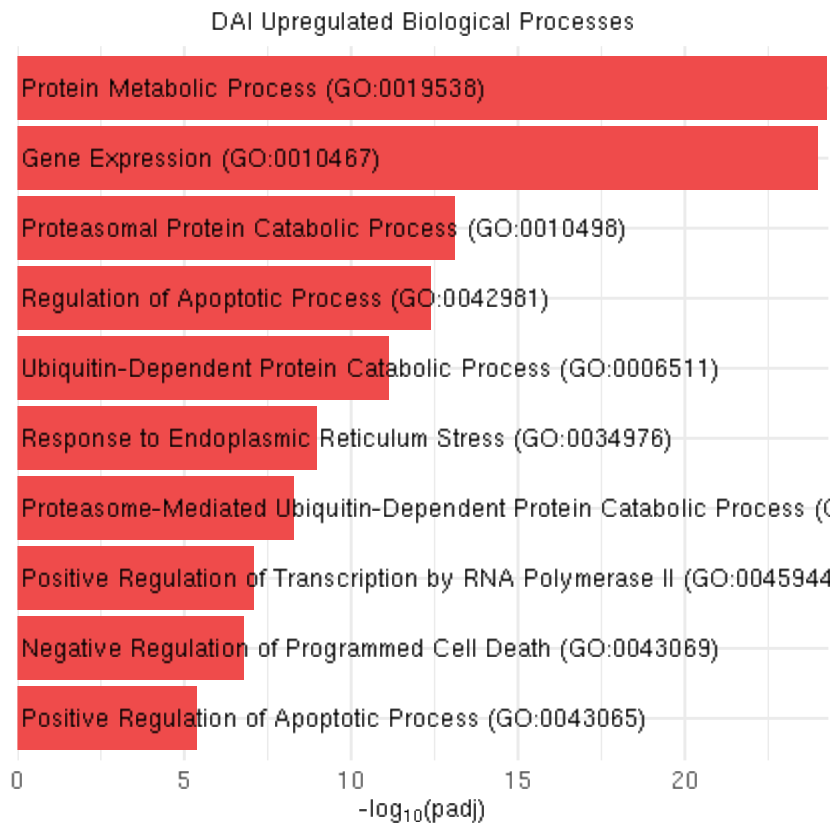

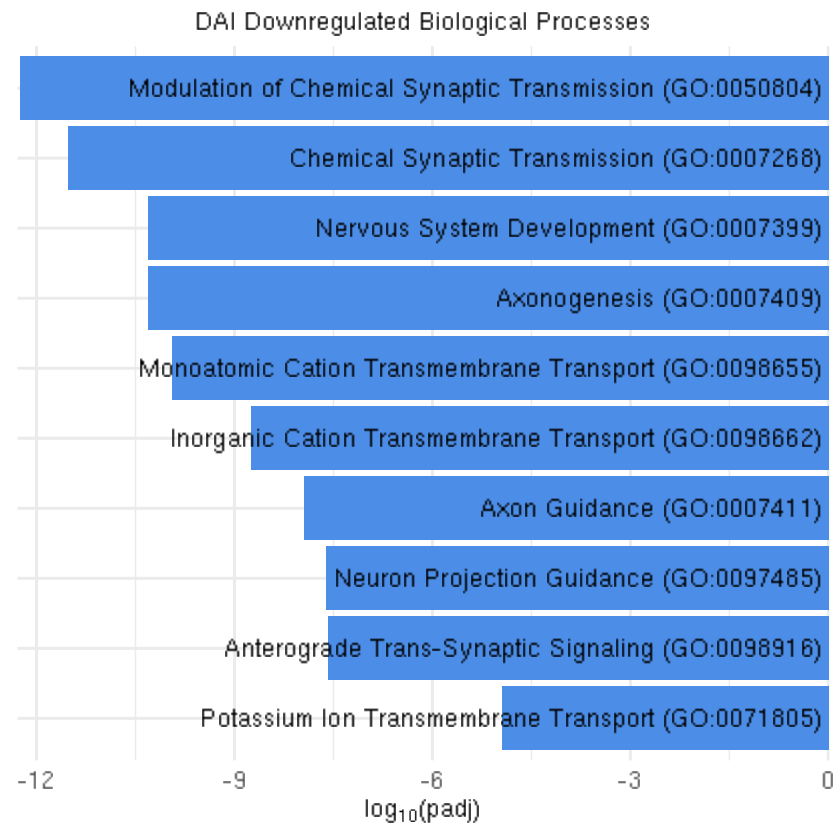

In [12]:
firebrick_df <- firebrick_df %>%
  mutate(combined_sig = -log10(padj.x * padj.y))

top_up <- firebrick_df %>%
  arrange(desc(combined_sig)) %>%
  slice_head(n = 10)

dodgerblue_df <- dodgerblue_df %>%
  mutate(combined_sig = -log10(padj.x * padj.y))

top_down <- dodgerblue_df %>%
  arrange(desc(combined_sig)) %>%
  slice_head(n = 10)

light_firebrick3  <- lighten("firebrick3",  0.2)
light_dodgerblue3 <- lighten("dodgerblue3", 0.2)

# -----------------------------
# Pull the terms to plot
# -----------------------------
up_terms   <- unique(top_up$Term)
down_terms <- unique(top_down$Term)

up_terms_df <- DAI_up_GO_BP %>%
  filter(Term %in% up_terms) %>%
  filter(!is.na(Adjusted.P.value), is.finite(Adjusted.P.value), Adjusted.P.value > 0) %>%
  mutate(
    Term = fct_reorder(Term, Adjusted.P.value, .desc = TRUE) 
  )

down_terms_df <- DAI_down_GO_BP %>%
  filter(Term %in% down_terms) %>%
  filter(!is.na(Adjusted.P.value), is.finite(Adjusted.P.value), Adjusted.P.value > 0) %>%
  mutate(
    Term = fct_reorder(Term, Adjusted.P.value, .desc = TRUE)
  )

# -----------------------------
# Up plot 
# -----------------------------
DAI_up_GO_BP_plot <- ggplot(up_terms_df, aes(x = -log10(Adjusted.P.value), y = Term)) +
  geom_col(fill = light_firebrick3) +
  geom_text(
    aes(x = 0.1, y = Term, label = Term),
    hjust = 0, vjust = 0.5, color = "black",
    inherit.aes = FALSE, size = 5
  ) +
  scale_x_continuous(expand = expansion(add = c(0, 0.05))) +
  ggtitle("DAI Upregulated Biological Processes") +
  labs(x = expression("-log"[10]*"(padj)"), y = NULL) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.y  = element_blank(),
    plot.title   = element_text(hjust = 0.5, size = 14),
    axis.title.x = element_text(size = 14),
    axis.text.x  = element_text(size = 14)
  )

DAI_up_GO_BP_plot

# -----------------------------
# Down plot 
# -----------------------------
DAI_down_GO_BP_plot <- ggplot(down_terms_df, aes(x = log10(Adjusted.P.value), y = Term)) +
  geom_col(fill = light_dodgerblue3) +
  geom_text(
    aes(x = -0.1, y = Term, label = Term),
    hjust = 1, vjust = 0.5, color = "black",
    inherit.aes = FALSE, size = 5
  ) +
  scale_x_continuous(expand = expansion(add = c(0.05, 0))) +
  ggtitle("DAI Downregulated Biological Processes") +
  labs(x = expression("log"[10]*"(padj)"), y = NULL) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.y  = element_blank(),
    axis.text.x  = element_text(size = 14),
    axis.title.x = element_text(size = 14),
    plot.title   = element_text(hjust = 0.5, size = 14)
  )

DAI_down_GO_BP_plot